<a href="https://colab.research.google.com/github/saturnnn7/heart-failure-ml/blob/main/heart_failure_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Failure Prediction
**Author:** Kyrylo Soprykin
**Dataset:** https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction  
**Task:** Binary Classification: Predicting Heart Failure Based on a Patient's Clinical Data.

In [1]:
# ----- Imports -----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import unittest

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings('ignore')

print("All libraries have been loaded ✓")

All libraries have been loaded ✓


In [2]:
# ----- Connecting Google Drive -----
from google.colab import drive
drive.mount('/content/drive')

# ----- Loading data -----
PATH = '/content/drive/MyDrive/ML_Project/heart.csv'
df = pd.read_csv(PATH)

print(f"Dataset uploaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(20)

Mounted at /content/drive
Dataset uploaded: 918 rows, 12 columns


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


## 1. Exploratory Data Analysis (EDA)

In [3]:
# ----- Dataset Information -----
print("=== DATA TYPES AND MISSING VALUES ===")
print(df.info())

print("\n=== STATISTICAL SUMMARY ===")
df.describe().round(2)

=== DATA TYPES AND MISSING VALUES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

=== STATISTICAL SUMMARY ===


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


In [4]:
# ----- Data Quality Check -----
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values ✓")

print(f"\n=== DUPLICATES ===")
print(f"Duplicates: {df.duplicated().sum()}")

print(f"\n=== CLASS BALANCE ===")
print(df['HeartDisease'].value_counts())
print(f"Percentage of positive cases: {df['HeartDisease'].mean():.1%}")

=== MISSING VALUES ===
No missing values ✓

=== DUPLICATES ===
Duplicates: 0

=== CLASS BALANCE ===
HeartDisease
1    508
0    410
Name: count, dtype: int64
Percentage of positive cases: 55.3%


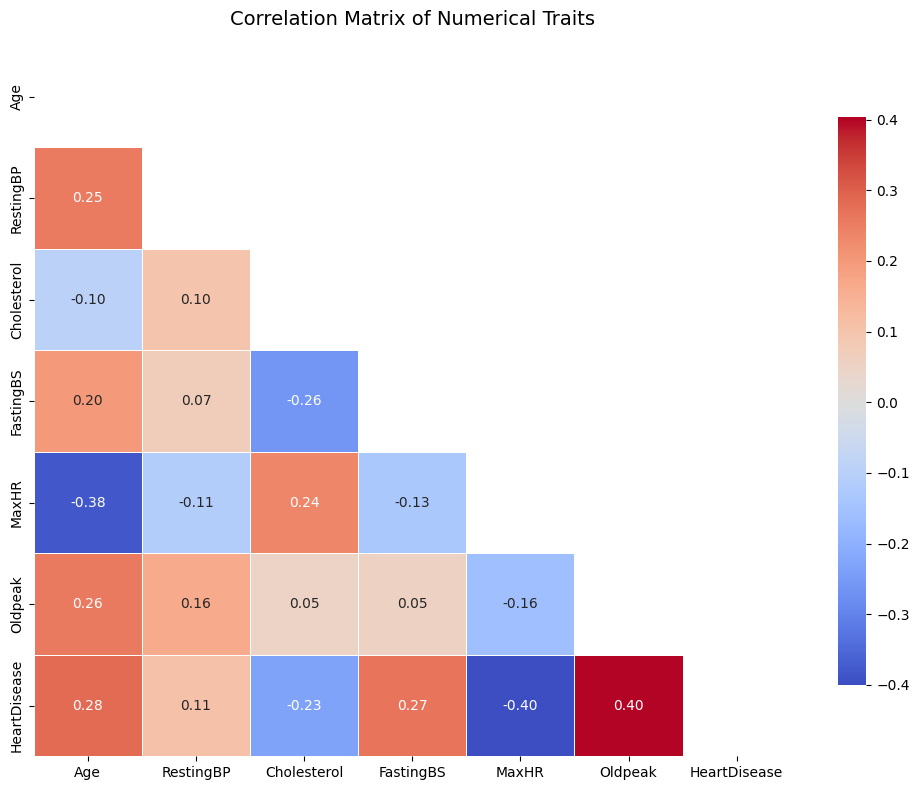

In [5]:
# ----- Correlation Matrix (numeric attributes only) -----
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Traits', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

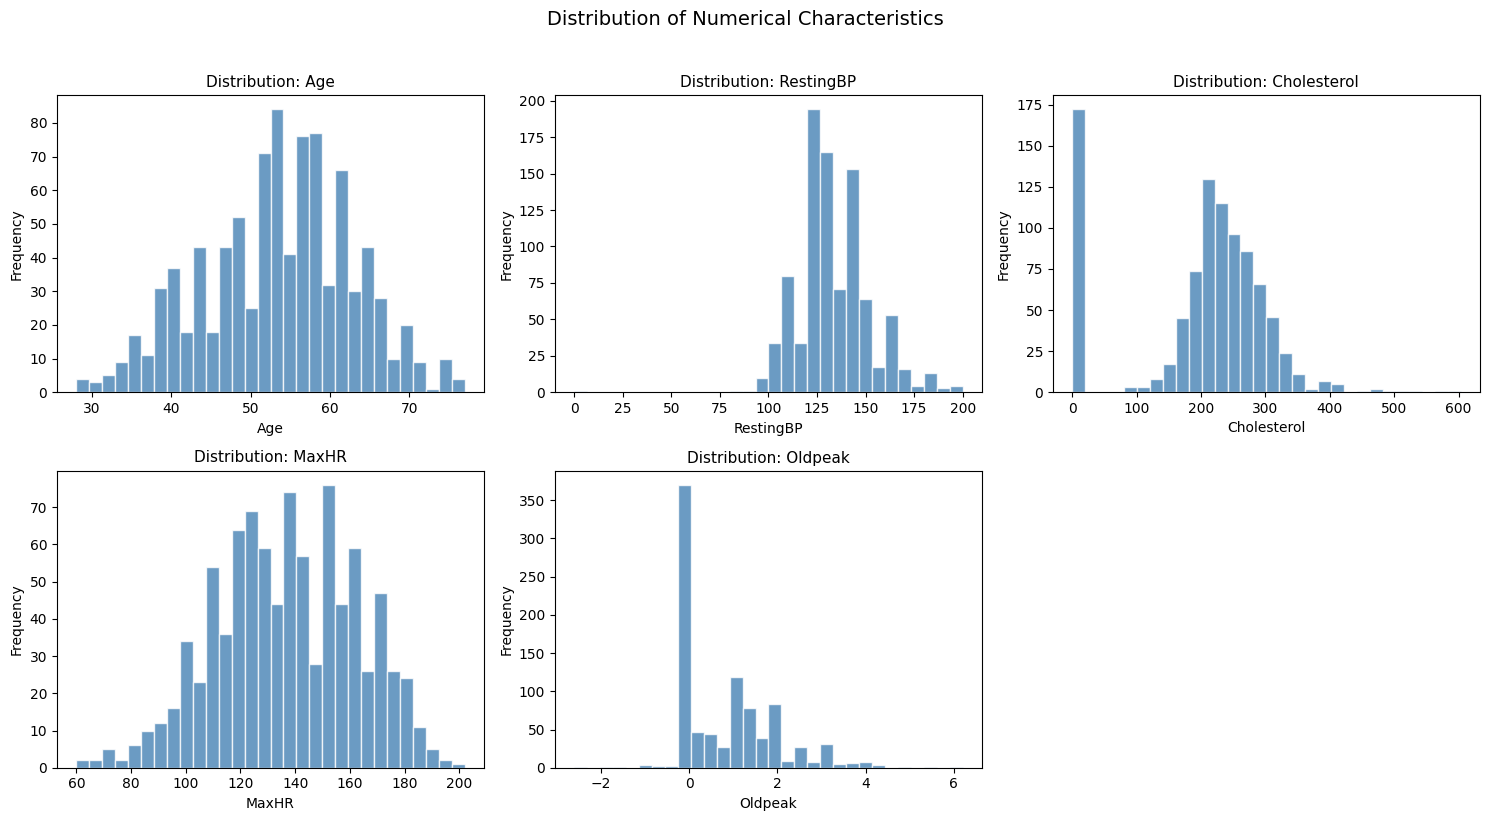

In [6]:
# ----- Histograms of Numerical Attributes -----
num_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution: {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')
plt.suptitle('Distribution of Numerical Characteristics', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

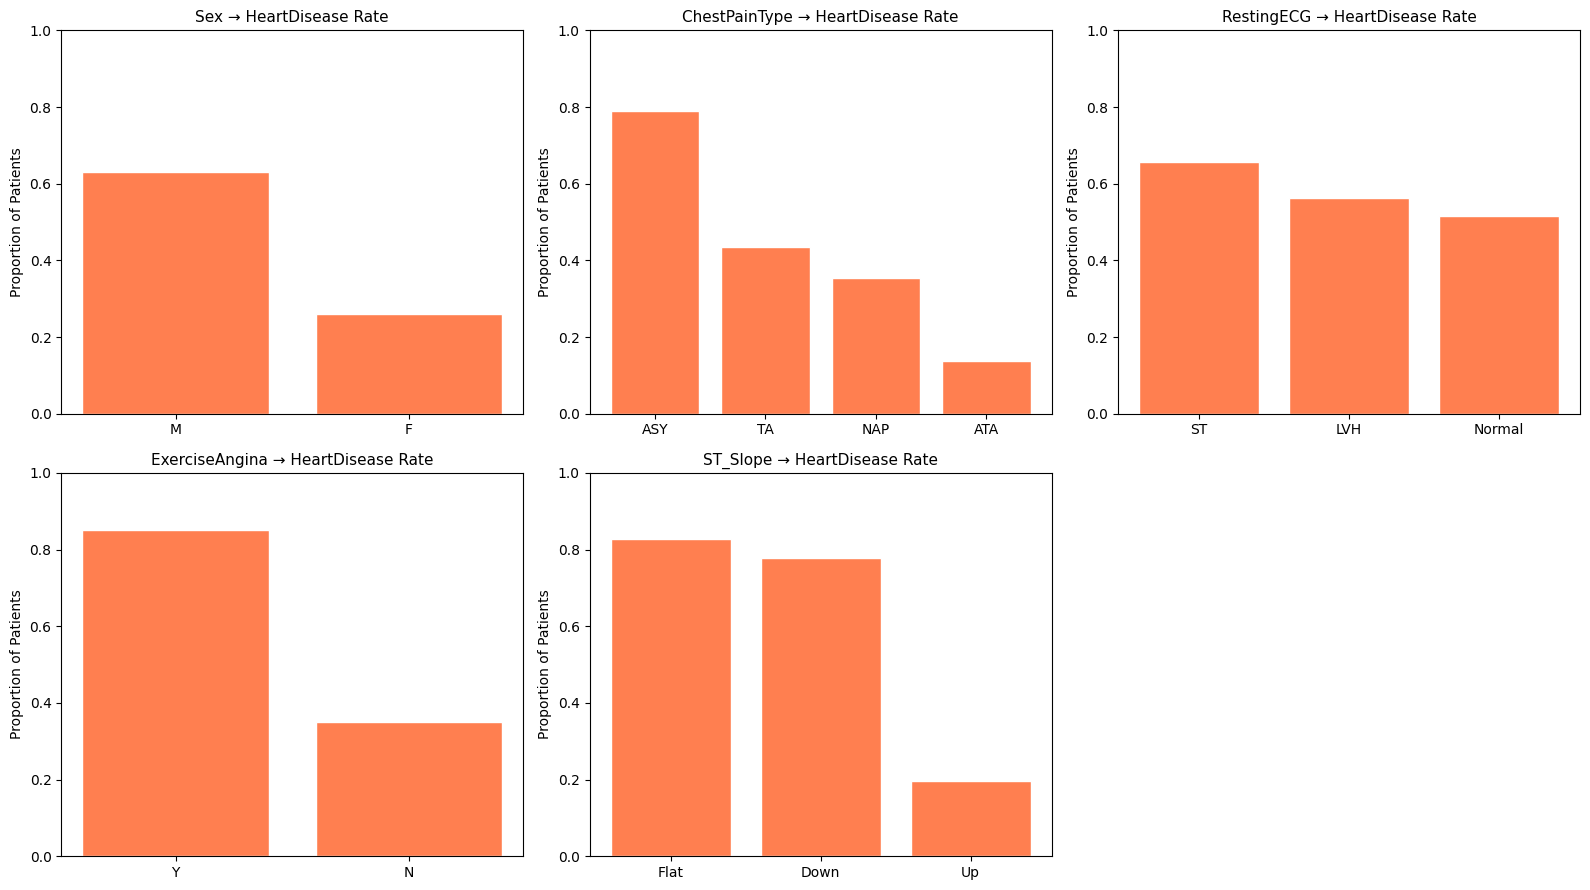

In [7]:
# ----- Categorical characteristics -----
cat_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ct = df.groupby(col)['HeartDisease'].mean().sort_values(ascending=False)
    axes[i].bar(ct.index, ct.values, color='coral', edgecolor='white')
    axes[i].set_title(f'{col} → HeartDisease Rate', fontsize=11)
    axes[i].set_ylabel('Proportion of Patients')
    axes[i].set_ylim(0, 1)

axes[-1].axis('off')
plt.tight_layout()
plt.savefig('categorical_features.png', dpi=150)
plt.show()

## 2. Feature Engineering and Data Preprocessing

In [17]:
# ----- Data Preprocessing Class (OOP) -----
class DataPreprocessor:
    """
    Preprocesses the Heart Failure dataset:
    - Encodes categorical features
    - Creates new features (feature engineering)
    - Scales numerical features
    """

    def __init__(self):
        self.scaler = StandardScaler()
        self.label_encoders = {}
        self.feature_names = None
        self.X_raw = None  # stores pre-scaling features for testing/inspection

    def _encode_categoricals(self, df: pd.DataFrame) -> pd.DataFrame:
        """Encodes categorical columns using LabelEncoder."""
        df = df.copy()
        cat_cols = df.select_dtypes(include='object').columns
        for col in cat_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            self.label_encoders[col] = le
        return df

    def _create_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Creates new features based on medical logic."""
        df = df.copy()

        # Age Groups
        df['AgeGroup'] = pd.cut(df['Age'],
                                bins=[0, 40, 55, 65, 100],
                                labels=[0, 1, 2, 3]).astype(int)

        # High cholesterol (>240 mg/dL — clinical threshold)
        df['HighCholesterol'] = (df['Cholesterol'] > 240).astype(int)

        # Zero Cholesterol — Suspicious Values (Dataset Artifact)
        df['ZeroCholesterol'] = (df['Cholesterol'] == 0).astype(int)

        # Maximum heart rate relative to age-specific norm (220 - age)
        df['HRRatio'] = df['MaxHR'] / (220 - df['Age'])

        # High resting blood pressure (>130 mmHg)
        df['HighRestingBP'] = (df['RestingBP'] > 130).astype(int)

        return df

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """Full preprocessing: encoding + new features + scaling."""
        df = self._encode_categoricals(df)
        df = self._create_features(df)

        # Extract the target variable
        X = df.drop('HeartDisease', axis=1)
        y = df['HeartDisease']

        # Save pre-scaling features for inspection and unit testing
        self.X_raw = X.copy()

        # Scaling
        X_scaled = pd.DataFrame(
            self.scaler.fit_transform(X),
            columns=X.columns
        )
        self.feature_names = list(X.columns)

        return X_scaled, y

    def get_feature_names(self) -> list:
        return self.feature_names


# ----- Start preprocessing -----
preprocessor = DataPreprocessor()
X, y = preprocessor.fit_transform(df.copy())

print(f"Number of features after Feature Engineering: {X.shape[1]}")
print(f"New features: AgeGroup, HighCholesterol, ZeroCholesterol, HRRatio, HighRestingBP")
print(f"\nClass distribution:\n{y.value_counts()}")
X.head()

Number of features after Feature Engineering: 16
New features: AgeGroup, HighCholesterol, ZeroCholesterol, HRRatio, HighRestingBP

Class distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,AgeGroup,HighCholesterol,ZeroCholesterol,HRRatio,HighRestingBP
0,-1.433140,0.515952,0.229032,0.410909,0.825070,-0.551341,0.017255,1.382928,-0.823556,-0.832432,1.052114,-1.807154,1.259331,-0.48017,0.945497,1.077033
1,-0.478484,-1.938163,1.275059,1.491752,-0.171961,-0.551341,0.017255,0.754157,-0.823556,0.105664,-0.596078,-0.543660,-0.794072,-0.48017,0.641165,1.077033
2,-1.751359,0.515952,0.229032,-0.129513,0.770188,-0.551341,1.601219,-1.525138,-0.823556,-0.832432,1.052114,-1.807154,1.259331,-0.48017,-2.008420,-0.928477
3,-0.584556,-1.938163,-0.816995,0.302825,0.139040,-0.551341,0.017255,-1.132156,1.214246,0.574711,-0.596078,-0.543660,-0.794072,-0.48017,-1.358700,1.077033
4,0.051881,0.515952,1.275059,0.951331,-0.034755,-0.551341,0.017255,-0.581981,-0.823556,-0.832432,1.052114,-0.543660,-0.794072,-0.48017,-0.605989,1.077033


## 3. Train-Test Split and Data Preparation

In [18]:
# ----- Train/Test Split -----
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,
    stratify=y           # preserve class balance
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Testing set:   {X_test.shape[0]} rows")
print(f"\nTrain class balance: {y_train.value_counts().to_dict()}")
print(f"Test class balance:  {y_test.value_counts().to_dict()}")

Training set:  734 rows
Testing set:   184 rows

Train class balance: {1: 406, 0: 328}
Test class balance:  {1: 102, 0: 82}


## 4. Model Training

In [19]:
# ----- Model Training and Evaluation Class (OOP) -----
class ModelTrainer:
    """
    Trains and compares multiple classifiers.
    """

    def __init__(self):
        self.models = {
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
            'Decision Tree':       DecisionTreeClassifier(random_state=42),
            'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
            'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
            'SVM':                 SVC(probability=True, random_state=42),
            'KNN':                 KNeighborsClassifier(),
        }
        self.results = {}
        self.trained_models = {}

    def train_all(self, X_train, X_test, y_train, y_test) -> pd.DataFrame:
        """Trains all models and returns a metrics summary DataFrame."""
        for name, model in self.models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            self.trained_models[name] = model
            self.results[name] = {
                'Model':     name,
                'Accuracy':  accuracy_score(y_test, y_pred),
                'Precision': precision_score(y_test, y_pred),
                'Recall':    recall_score(y_test, y_pred),
                'F1':        f1_score(y_test, y_pred),
            }

        results_df = pd.DataFrame(self.results.values()).sort_values('F1', ascending=False)
        results_df = results_df.set_index('Model').round(4)
        return results_df

    def get_best_model(self, metric='F1'):
        """Returns the best trained model based on the specified metric."""
        best_name = max(self.results, key=lambda k: self.results[k][metric])
        return best_name, self.trained_models[best_name]


# ----- Train all models -----
trainer = ModelTrainer()
results_df = trainer.train_all(X_train, X_test, y_train, y_test)

print("=== MODEL COMPARISON ===")
results_df

=== MODEL COMPARISON ===


,Accuracy,Precision,Recall,F1
Model,,,,
Gradient Boosting,0.8913,0.9020,0.9020,0.9020
SVM,0.8804,0.8704,0.9216,0.8952
Random Forest,0.8804,0.8922,0.8922,0.8922
KNN,0.8804,0.8922,0.8922,0.8922
Logistic Regression,0.8587,0.8519,0.9020,0.8762
Decision Tree,0.7772,0.8352,0.7451,0.7876


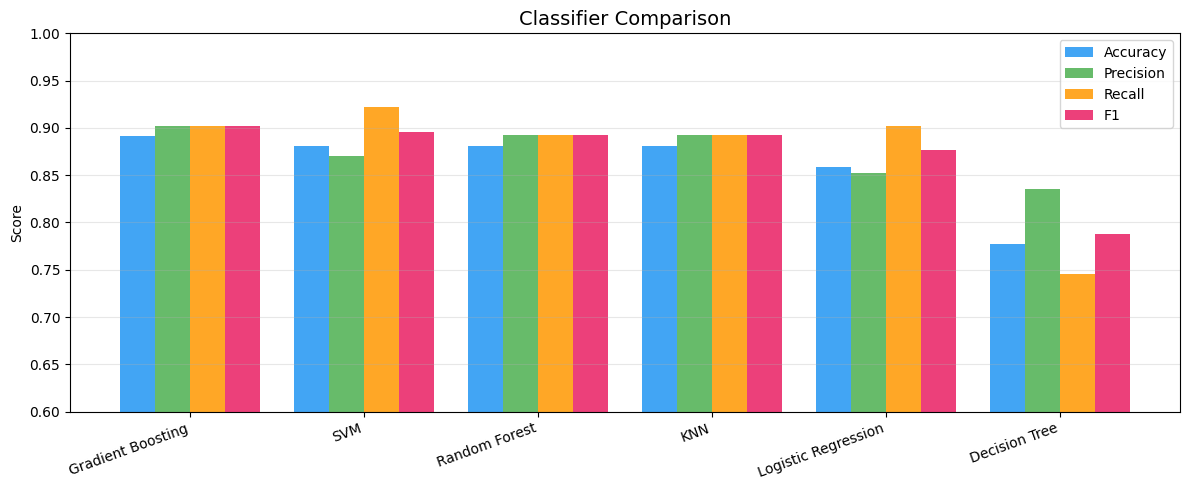

In [20]:
# ----- Model Comparison Chart -----
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(results_df))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, rotation=20, ha='right')
ax.set_ylim(0.6, 1.0)
ax.set_ylabel('Score')
ax.set_title('Classifier Comparison', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 5. Fine-tuning the Best Model (GridSearchCV)

In [21]:
# ----- Fine-tuning Random Forest via GridSearchCV -----
best_name, best_model = trainer.get_best_model('F1')
print(f"The Best Entry-Level Model: {best_name}")

# Parameter grid for tuning
param_grid = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n=== FINE-TUNING RESULTS ===")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1 (CV):    {grid_search.best_score_:.4f}")

# Evaluate on test set
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)

print(f"\n=== METRICS AFTER FINE-TUNING ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_tuned):.4f}")

The Best Entry-Level Model: Gradient Boosting
Fitting 5 folds for each of 72 candidates, totalling 360 fits

=== FINE-TUNING RESULTS ===
Best parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Best F1 (CV):    0.8794

=== METRICS AFTER FINE-TUNING ===
Accuracy:  0.9022
Precision: 0.8962
Recall:    0.9314
F1:        0.9135


## 6. Final Model Evaluation

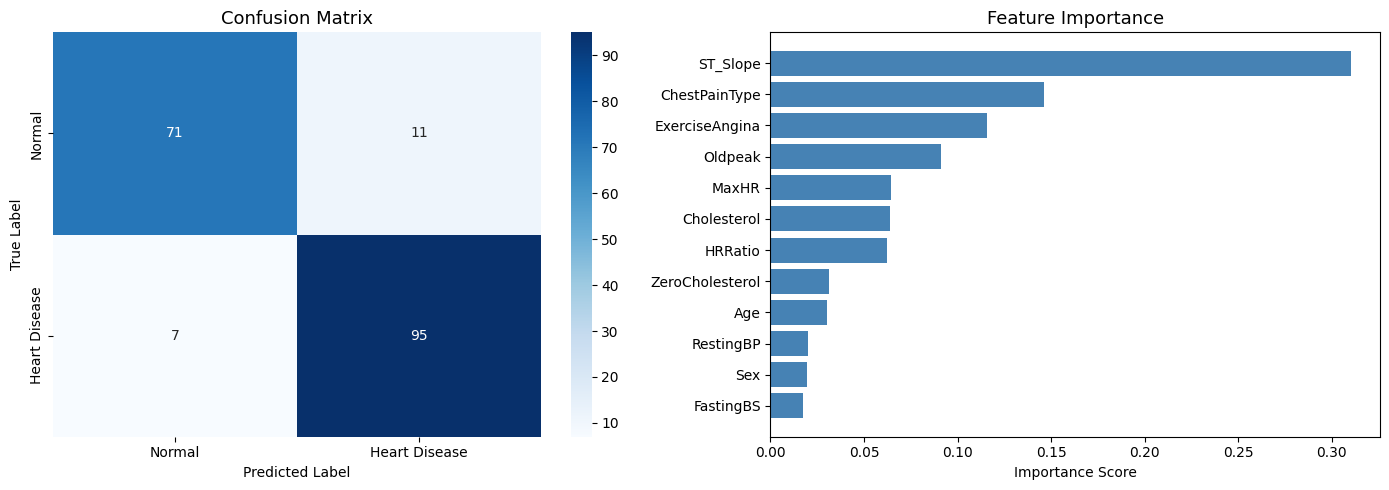


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

Negative (0)       0.91      0.87      0.89        82
Positive (1)       0.90      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



In [22]:
# ----- Confusion Matrix -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Heart Disease'],
            yticklabels=['Normal', 'Heart Disease'])
axes[0].set_title('Confusion Matrix', fontsize=13)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Feature Importance
importances = pd.Series(
    tuned_model.feature_importances_,
    index=preprocessor.get_feature_names()
).sort_values(ascending=True).tail(12)

axes[1].barh(importances.index, importances.values, color='steelblue')
axes[1].set_title('Feature Importance', fontsize=13)
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('final_evaluation.png', dpi=150)
plt.show()

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_tuned,
                            target_names=['Negative (0)', 'Positive (1)']))

In [23]:
# ----- Cross-Validation -----
cv_scores = cross_val_score(tuned_model, X, y, cv=5, scoring='f1')

print("=== CROSS-VALIDATION (5-fold) ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean F1-Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

=== CROSS-VALIDATION (5-fold) ===
  Fold 1: 0.8821
  Fold 2: 0.8421
  Fold 3: 0.8707
  Fold 4: 0.8531
  Fold 5: 0.7732

Mean F1-Score: 0.8442 ± 0.0381


In [24]:
# ----- Model Serialization -----
MODEL_PATH = '/content/drive/MyDrive/ML_Project/heart_failure_model.pkl'
joblib.dump(tuned_model, MODEL_PATH)
print(f"Model saved successfully to: {MODEL_PATH} ✓")

# ----- Export Metrics Table to CSV -----
CSV_PATH = '/content/drive/MyDrive/ML_Project/model_results.csv'
results_df.to_csv(CSV_PATH)
print(f"Metrics saved successfully to: {CSV_PATH} ✓")

# ----- Project Summary -----
print("\n=== PROJECT SUMMARY ===")
print(f"Dataset:          Heart Failure Prediction ({df.shape[0]} patients)")
print(f"Best Model:       Random Forest (fine-tuned)")
print(f"F1 Score:         {f1_score(y_test, y_pred_tuned):.4f}")
print(f"Accuracy:         {accuracy_score(y_test, y_pred_tuned):.4f}")

Model saved successfully to: /content/drive/MyDrive/ML_Project/heart_failure_model.pkl ✓
Metrics saved successfully to: /content/drive/MyDrive/ML_Project/model_results.csv ✓

=== PROJECT SUMMARY ===
Dataset:          Heart Failure Prediction (918 patients)
Best Model:       Random Forest (fine-tuned)
F1 Score:         0.9135
Accuracy:         0.9022


## 7. Unit tests

In [25]:
# ----- Unit Tests -----
class TestDataPreprocessor(unittest.TestCase):

    def setUp(self):
        """Create a small dummy dataset for testing."""
        self.sample_df = pd.DataFrame({
            'Age':            [45, 60, 35, 70],
            'Sex':            ['M', 'F', 'M', 'F'],
            'ChestPainType':  ['ATA', 'ASY', 'NAP', 'TA'],
            'RestingBP':      [120, 140, 110, 160],
            'Cholesterol':    [200, 0, 250, 300],
            'FastingBS':      [0, 1, 0, 1],
            'RestingECG':     ['Normal', 'ST', 'Normal', 'LVH'],
            'MaxHR':          [150, 120, 170, 100],
            'ExerciseAngina': ['N', 'Y', 'N', 'Y'],
            'Oldpeak':        [0.0, 2.5, 0.5, 1.0],
            'ST_Slope':       ['Up', 'Flat', 'Up', 'Down'],
            'HeartDisease':   [0, 1, 0, 1],
        })
        self.preprocessor = DataPreprocessor()

    def test_output_shape(self):
        """Preprocessing should result in more columns due to feature engineering."""
        X, y = self.preprocessor.fit_transform(self.sample_df)
        original_features = self.sample_df.shape[1] - 1  # without target
        self.assertGreater(X.shape[1], original_features)

    def test_no_missing_values(self):
        """There should be no NaN values after preprocessing."""
        X, y = self.preprocessor.fit_transform(self.sample_df)
        self.assertEqual(X.isnull().sum().sum(), 0)

    def test_target_binary(self):
        """The target variable must contain only 0 and 1."""
        _, y = self.preprocessor.fit_transform(self.sample_df)
        self.assertTrue(set(y.unique()).issubset({0, 1}))

    def test_high_cholesterol_feature(self):
        """HighCholesterol feature should be 1 if Cholesterol > 240."""
        X, _ = self.preprocessor.fit_transform(self.sample_df)
        # Row index 2: Cholesterol=250 -> expected output is 1
        self.assertEqual(X['HighCholesterol'].iloc[2], 1)

    def test_zero_cholesterol_feature(self):
        """ZeroCholesterol feature should be 1 if Cholesterol == 0."""
        X, _ = self.preprocessor.fit_transform(self.sample_df)
        # Check raw (pre-scaling) value — scaler changes binary 0/1 to floats
        # Row index 1: Cholesterol=0 -> expected raw value is 1
        self.assertEqual(self.preprocessor.X_raw['ZeroCholesterol'].iloc[1], 1)


class TestModelTrainer(unittest.TestCase):

    def setUp(self):
        """Create simple dummy numerical data for testing."""
        np.random.seed(42)
        self.X_train = pd.DataFrame(np.random.randn(100, 5))
        self.X_test  = pd.DataFrame(np.random.randn(20, 5))
        self.y_train = pd.Series(np.random.randint(0, 2, 100))
        self.y_test  = pd.Series(np.random.randint(0, 2, 20))

    def test_all_models_trained(self):
        """All 6 models should be trained successfully."""
        trainer = ModelTrainer()
        results = trainer.train_all(self.X_train, self.X_test,
                                    self.y_train, self.y_test)
        self.assertEqual(len(results), 6)

    def test_results_have_metrics(self):
        """The results table must contain the specified evaluation metrics."""
        trainer = ModelTrainer()
        results = trainer.train_all(self.X_train, self.X_test,
                                    self.y_train, self.y_test)
        for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
            self.assertIn(col, results.columns)

    def test_accuracy_range(self):
        """Accuracy score must be within the range [0, 1]."""
        trainer = ModelTrainer()
        results = trainer.train_all(self.X_train, self.X_test,
                                    self.y_train, self.y_test)
        self.assertTrue((results['Accuracy'] >= 0).all())
        self.assertTrue((results['Accuracy'] <= 1).all())


# ----- Run Tests -----
loader = unittest.TestLoader()
suite = unittest.TestSuite()
suite.addTests(loader.loadTestsFromTestCase(TestDataPreprocessor))
suite.addTests(loader.loadTestsFromTestCase(TestModelTrainer))

runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)

test_high_cholesterol_feature (__main__.TestDataPreprocessor.test_high_cholesterol_feature)
HighCholesterol feature should be 1 if Cholesterol > 240. ... ok
test_no_missing_values (__main__.TestDataPreprocessor.test_no_missing_values)
There should be no NaN values after preprocessing. ... ok
test_output_shape (__main__.TestDataPreprocessor.test_output_shape)
Preprocessing should result in more columns due to feature engineering. ... ok
test_target_binary (__main__.TestDataPreprocessor.test_target_binary)
The target variable must contain only 0 and 1. ... ok
test_zero_cholesterol_feature (__main__.TestDataPreprocessor.test_zero_cholesterol_feature)
ZeroCholesterol feature should be 1 if Cholesterol == 0. ... ok
test_accuracy_range (__main__.TestModelTrainer.test_accuracy_range)
Accuracy score must be within the range [0, 1]. ... ok
test_all_models_trained (__main__.TestModelTrainer.test_all_models_trained)
All 6 models should be trained successfully. ... ok
test_results_have_metrics (__